# Retail Sales Pulse — From Analysis to Pipeline

**Prepared by:** Harshith.K  
**Assignment:** Phase 1 — Mini Use Case 01  
**Industry:** Retail / E-commerce  

## CBIM Problem Canvas

| Canvas Element | Response |
|---|---|
| **Situation (S)** | A regional retail chain operates 12 stores across six Andhra Pradesh cities and five product categories. It has 107,836 historical transactions from January to June 2026 and receives weekly sales data through an API-style JSON response. The Head of Retail Operations is preparing Q3 promotional decisions. |
| **Complication (C)** | The business does not have a clear, repeatable process for identifying underperforming stores, declining categories, weak sales periods or unusual revenue drops. Weekly analysis is manual, and invalid API records could produce misleading reports. |
| **Question (Q)** | Which stores, categories and time periods are driving performance gaps, and how can a reliable weekly pipeline validate incoming data, compare it with historical performance and deliver actionable insights? |
| **Single Source of Truth (SSOT)** | The CSV is the authoritative historical baseline, while the clean JSON is the latest weekly sales signal. The corrupt JSON is only a validation test and must not be used for business reporting. |
| **Success Definition** | **Part 1:** Produce specific, data-backed findings and one actionable recommendation. **Part 2:** Verify all 4,291 clean records, detect all three corrupt-data issues, halt invalid processing and generate a computed weekly summary using the historical baseline. |
| **Primary Stakeholder** | The Head of Retail Operations, who needs a validated Monday sales summary to allocate Q3 promotional spending and investigate store or category underperformance. |

# Part 1 — Retail Sales Pulse: Exploratory Data Analysis

## 5.1 Load and Inspect the Data

The historical sales dataset is loaded and inspected to understand its size, structure, data types, completeness and numerical distribution before beginning the business analysis.

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [323]:
sales_df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

print("Dataset loaded successfully.")
print(f"Rows: {sales_df.shape[0]:,}")
print(f"Columns: {sales_df.shape[1]}")

Dataset loaded successfully.
Rows: 107,836
Columns: 10


In [324]:
sales_df.columns.tolist()

['transaction_id',
 'date',
 'store_id',
 'store_city',
 'category',
 'product_name',
 'units_sold',
 'unit_price',
 'revenue',
 'discount_pct']

In [325]:
sales_df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,3075.46,5843.37,5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,11598.06,11598.06,0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,5738.37,15493.60,10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,3281.28,9351.65,5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,1917.14,1917.14,0


In [326]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107836 entries, 0 to 107835
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaction_id  107836 non-null  str    
 1   date            107836 non-null  str    
 2   store_id        107836 non-null  str    
 3   store_city      107836 non-null  str    
 4   category        107836 non-null  str    
 5   product_name    107836 non-null  str    
 6   units_sold      107836 non-null  int64  
 7   unit_price      107836 non-null  float64
 8   revenue         107836 non-null  float64
 9   discount_pct    107836 non-null  int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 8.2 MB


In [327]:
sales_df["date"] = pd.to_datetime(
    sales_df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

In [328]:
sales_df["date"].dtype

dtype('<M8[us]')

In [329]:
sales_df["date"].isna().sum()

np.int64(0)

In [330]:
sales_df["discount_pct"].unique() # checking whether the discount percentage column has decimal values or not

array([ 5,  0, 10, 20, 15])

In [331]:
sales_df.isnull().sum() #missing values in each column

transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64

In [332]:
total_missing_values = sales_df.isnull().sum().sum()
print(f"Total missing values: {total_missing_values:,}") #total missing values in the dataset

Total missing values: 0


In [333]:
duplicate_rows = sales_df.duplicated().sum() # checking for exact duplicate rows in the dataset

print(f"Exact duplicate rows: {duplicate_rows}")

Exact duplicate rows: 0


In [334]:
duplicate_transaction_ids = sales_df["transaction_id"].duplicated().sum()

print(f"Duplicate transaction IDs: {duplicate_transaction_ids}") #checking for duplicate transaction IDs in the dataset

Duplicate transaction IDs: 0


In [335]:
sales_df[
    (sales_df["units_sold"] <= 0)         #checking whether dataset following the basic business rules or not
    | (sales_df["unit_price"] <= 0)
    | (sales_df["revenue"] <= 0)
    | (~sales_df["discount_pct"].between(0, 100))
]

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct


In [336]:
expected_revenue = (     #verifying the revenue calculation based on the formula: revenue = units_sold * unit_price * (1 - discount_pct / 100)
    sales_df["units_sold"]
    * sales_df["unit_price"]
    * (1 - sales_df["discount_pct"] / 100)
).round(2)

revenue_mismatch_mask = ~np.isclose(
    sales_df["revenue"],
    expected_revenue,
    atol=0.01
)

revenue_mismatches = sales_df.loc[
    revenue_mismatch_mask,
    [
        "transaction_id",
        "units_sold",
        "unit_price",
        "discount_pct",
        "revenue"
    ]
].copy()

revenue_mismatches["expected_revenue"] = (
    expected_revenue[revenue_mismatch_mask]
)

print(
    f"Revenue calculation mismatches: "
    f"{len(revenue_mismatches):,}"
)

revenue_mismatches.head()

Revenue calculation mismatches: 0


,transaction_id,units_sold,unit_price,discount_pct,revenue,expected_revenue


In [337]:
store_city_mapping = (
    sales_df.groupby("store_id")["store_city"]     #checking category and store consistency store id should always map to the same city
    .nunique()
)

inconsistent_stores = store_city_mapping[
    store_city_mapping > 1
]

print(
    f"Store IDs mapped to multiple cities: "
    f"{len(inconsistent_stores)}"
)

Store IDs mapped to multiple cities: 0


In [338]:
product_category_mapping = (              # verifying that every product maps to only one category.
    sales_df.groupby("product_name")["category"]
    .nunique()
)

inconsistent_products = product_category_mapping[
    product_category_mapping > 1
]

print(
    f"Products mapped to multiple categories: "
    f"{len(inconsistent_products)}"
)

Products mapped to multiple categories: 0


In [339]:
sales_df.describe().T #statistical summary of the dataset

,count,mean,min,25%,50%,75%,max,std
date,107836,2026-04-01 18:11:48.275529,2026-01-01 00:00:00,2026-02-15 00:00:00,2026-04-02 00:00:00,2026-05-17 00:00:00,2026-06-30 00:00:00,NaN
units_sold,107836.0,2.583488,1.0,1.0,2.0,3.0,13.0,1.471616
unit_price,107836.0,1778.097787,50.02,274.8275,488.45,1039.5225,44990.14,5053.631792
revenue,107836.0,4263.920924,40.04,467.7725,1034.615,2473.335,355090.88,14243.244169
discount_pct,107836.0,7.228152,0.0,0.0,5.0,10.0,20.0,6.730445


In [340]:
store_product_coverage = (         #every store has same products and categories
    sales_df.groupby(
        ["store_id", "store_city"],
        as_index=False
    )
    .agg(
        unique_products=("product_name", "nunique"),
        unique_categories=("category", "nunique")
    )
)

store_product_coverage

,store_id,store_city,unique_products,unique_categories
0,S01,Vijayawada,25,5
1,S02,Vijayawada,25,5
2,S03,Guntur,25,5
3,S04,Guntur,25,5
4,S05,Rajahmundry,25,5
5,S06,Rajahmundry,25,5
6,S07,Tirupati,25,5
7,S08,Tirupati,25,5
8,S09,Nellore,25,5
9,S10,Nellore,25,5


### Descriptive Statistics — Business Observations

1. **Sales value is strongly influenced by high-value transactions.** The average transaction revenue is approximately ₹4,264, while the median is only about ₹1,035. This large difference indicates a right-skewed distribution in which a smaller number of expensive purchases, likely from categories such as Electronics, raise the overall average. Therefore, average revenue alone should not be treated as a typical customer transaction.

2. **The business handles a mix of low-priced and premium products.** The median unit price is approximately ₹488, whereas the maximum is nearly ₹44,990. This wide price range means that store revenue comparisons may be influenced by category and product mix, not only by transaction volume or operational performance.

3. **Discounting appears controlled rather than extreme.** The median discount is 5%, most transactions receive no more than a 10% discount, and the maximum is 20%. However, the dataset contains revenue but no cost or profit information, so it cannot determine whether these discounts improve profitability.

### Data Quality Conclusion

The historical dataset contains no missing values, duplicate transactions, invalid dates or basic business-rule violations. Revenue was verified using the relationship between units sold, unit price and discount percentage, with no material mismatches found within a one-paisa rounding tolerance. Store-to-city and product-to-category mappings were also consistent.

## 5.2 Revenue by Store

This analysis calculates the total six-month revenue generated by each store and ranks the stores from highest to lowest to identify performance differences across locations.

In [341]:
store_revenue = (
    sales_df.groupby(["store_id", "store_city"], as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

store_revenue

,store_id,store_city,revenue
0,S01,Vijayawada,59055493.38
1,S03,Guntur,53175162.00
2,S07,Tirupati,48537659.56
3,S06,Rajahmundry,44969840.50
4,S02,Vijayawada,42069856.33
5,S04,Guntur,41379797.16
6,S08,Tirupati,35032561.12
7,S09,Nellore,33452441.09
8,S11,Kakinada,32780138.71
9,S05,Rajahmundry,25157347.02


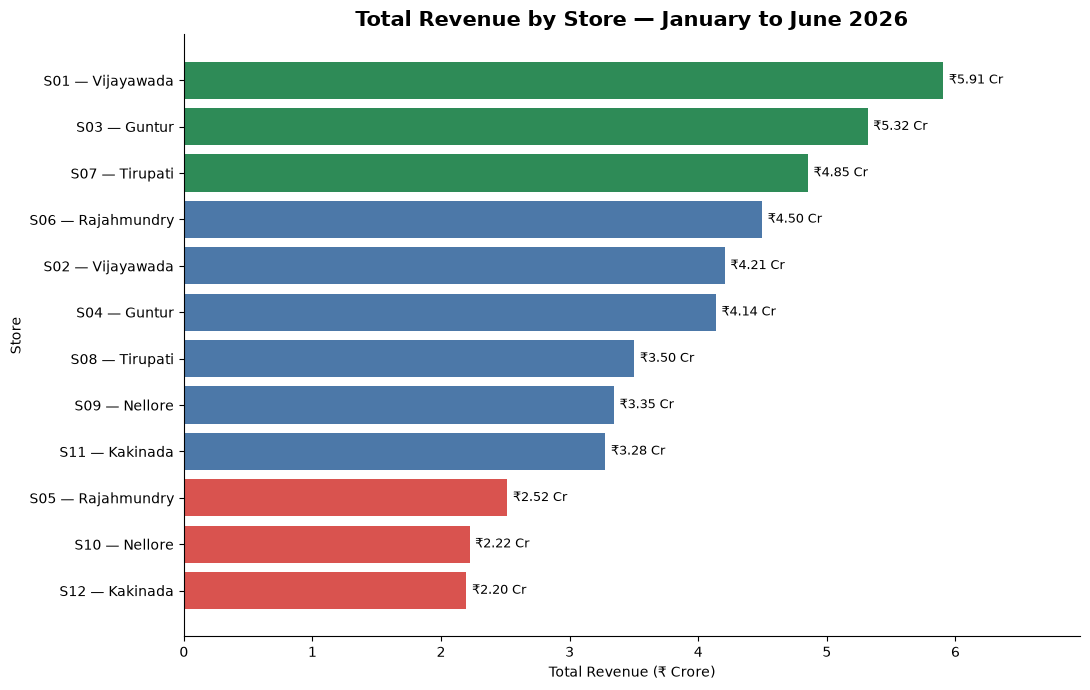

In [342]:
# Converting revenue into crores for easier business interpretation
store_revenue["revenue_crore"] = (
    store_revenue["revenue"] / 1_00_00_000
)

# Creating a readable store label
store_revenue["store_label"] = (
    store_revenue["store_id"] + " — " + store_revenue["store_city"]
)

# Highlights the top three, middle six and bottom three stores
colors = (
    ["#2E8B57"] * 3 +   # Top three: green
    ["#4C78A8"] * 6 +   # Middle stores: blue
    ["#D9534F"] * 3     # Bottom three: red
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    store_revenue["store_label"],
    store_revenue["revenue_crore"],
    color=colors
)

# Keeps the highest-revenue store at the top
ax.invert_yaxis()

ax.set_title(
    "Total Revenue by Store — January to June 2026",
    fontsize=15,
    fontweight="bold"
)
ax.set_xlabel("Total Revenue (₹ Crore)")
ax.set_ylabel("Store")

# Displays revenue values on the bars
ax.bar_label(
    bars,
    labels=[
        f"₹{value:.2f} Cr"
        for value in store_revenue["revenue_crore"]
    ],
    padding=4,
    fontsize=9
)

# Adds space for the value labels
ax.set_xlim(
    0,
    store_revenue["revenue_crore"].max() * 1.18
)

ax.spines["top"].set_visible(False)   #These lines hide the top and right borders of the chart
ax.spines["right"].set_visible(False)

plt.tight_layout()  # it adjusts the graphs margins and spacing
plt.show()

In [343]:
top_store = store_revenue.iloc[0]
bottom_store = store_revenue.iloc[-1]

revenue_gap = top_store["revenue"] - bottom_store["revenue"]

percentage_below_top = (
    revenue_gap / top_store["revenue"]
) * 100

print(
    f"Top store: {top_store['store_id']} — "
    f"{top_store['store_city']} "
    f"(₹{top_store['revenue_crore']:.2f} Cr)"
)

print(
    f"Bottom store: {bottom_store['store_id']} — "
    f"{bottom_store['store_city']} "
    f"(₹{bottom_store['revenue_crore']:.2f} Cr)"
)

print(f"Revenue gap: ₹{revenue_gap / 1_00_00_000:.2f} Cr")
print(f"Bottom store is {percentage_below_top:.1f}% below the top store")

Top store: S01 — Vijayawada (₹5.91 Cr)
Bottom store: S12 — Kakinada (₹2.20 Cr)
Revenue gap: ₹3.71 Cr
Bottom store is 62.8% below the top store


In [344]:
store_supporting_metrics = (            # summary table for each store with total revenue, transaction count, total units sold, and average transaction revenue
    sales_df.groupby(
        ["store_id", "store_city"],
        as_index=False
    )
    .agg(
        total_revenue=("revenue", "sum"),
        transaction_count=("transaction_id", "nunique"),
        total_units_sold=("units_sold", "sum"),
        average_transaction_revenue=("revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index(drop=True)
)

store_supporting_metrics["total_revenue_crore"] = (
    store_supporting_metrics["total_revenue"]
    / 1_00_00_000
)

store_supporting_metrics[
    [
        "store_id",
        "store_city",
        "total_revenue_crore",
        "transaction_count",
        "total_units_sold",
        "average_transaction_revenue"
    ]
].round(2)

,store_id,store_city,total_revenue_crore,transaction_count,total_units_sold,average_transaction_revenue
0,S01,Vijayawada,5.91,13270,34367,4450.30
1,S03,Guntur,5.32,12330,31880,4312.67
2,S07,Tirupati,4.85,11308,28918,4292.33
3,S06,Rajahmundry,4.50,10488,26983,4287.74
4,S02,Vijayawada,4.21,9813,25626,4287.16
5,S04,Guntur,4.14,9412,24254,4396.49
6,S08,Tirupati,3.50,8641,22410,4054.23
7,S09,Nellore,3.35,8355,21778,4003.88
8,S11,Kakinada,3.28,7738,20180,4236.25
9,S05,Rajahmundry,2.52,5990,15393,4199.89


### Business Interpretation

S01 in Vijayawada generated the highest six-month revenue at approximately **₹5.91 crore**, while S12 in Kakinada generated approximately **₹2.20 crore**, creating a gap of **₹3.71 crore**. Although S12 is 62.8% below S01 in total revenue, their average transaction revenues are nearly identical at approximately ₹4,428 and ₹4,450 respectively.

This indicates that the performance gap is primarily associated with sales volume: S01 recorded 13,270 transactions compared with only 4,963 for S12. Before reducing promotional investment in S12, the operations team should investigate customer footfall, store capacity, inventory availability and local demand to understand why transaction volume is substantially lower.

## 5.3 Category Performance Over Time

Monthly revenue is analysed across all five product categories to identify growth, decline and stability patterns between January and June 2026.

In [345]:
sales_df["month"] = sales_df["date"].dt.to_period("M") #creating a new month column

sales_df[["date", "month"]].head()

,date,month
0,2026-01-01,2026-01
1,2026-01-01,2026-01
2,2026-01-01,2026-01
3,2026-01-01,2026-01
4,2026-01-01,2026-01


In [346]:
monthly_category_revenue = (
    sales_df.groupby(
        ["month", "category"],
        as_index=False
    )["revenue"]
    .sum()
)

monthly_category_revenue.head(10)

,month,category,revenue
0,2026-01,Apparel,10049916.78
1,2026-01,Electronics,45686596.63
2,2026-01,Grocery,7307011.34
3,2026-01,Home & Kitchen,15130871.54
4,2026-01,Personal Care,6593734.81
5,2026-02,Apparel,9510938.10
6,2026-02,Electronics,38988602.50
7,2026-02,Grocery,6534957.35
8,2026-02,Home & Kitchen,13006413.31
9,2026-02,Personal Care,5792754.97


In [347]:
print(
    f"Month-category combinations: "
    f"{len(monthly_category_revenue)}"
)

Month-category combinations: 30


In [348]:
category_monthly_pivot = monthly_category_revenue.pivot(
    index="month",
    columns="category",   #comparison table with months as rows and categories as columns, showing revenue for each category in each month
    values="revenue"    #pivot changes the shape of the data, making it easier to analyze and visualize trends across different categories over time
)

category_monthly_pivot

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01,10049916.78,45686596.63,7307011.34,15130871.54,6593734.81
2026-02,9510938.10,38988602.50,6534957.35,13006413.31,5792754.97
2026-03,11540439.47,40846509.47,7132787.06,14362119.50,6808029.34
2026-04,11681806.66,37092265.09,7047399.58,13431147.66,6417868.13
2026-05,13219535.79,34226926.43,7232706.20,13581886.25,7298818.71
2026-06,13476952.88,29686824.81,7047719.23,12333283.07,6737354.12


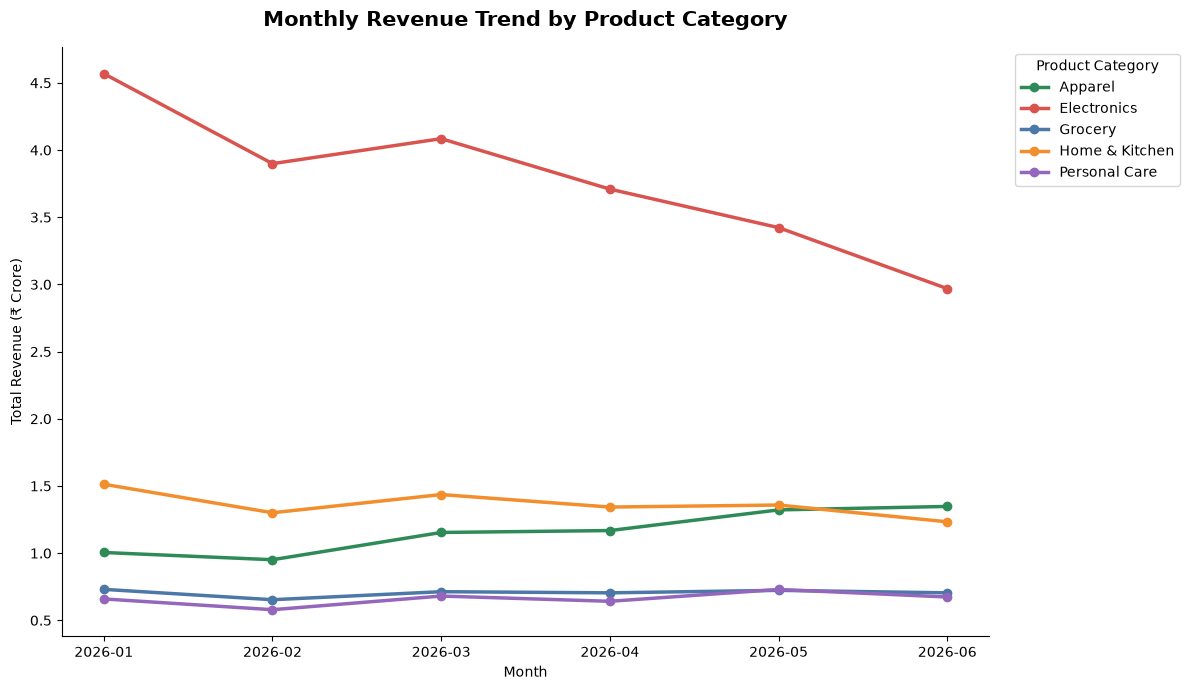

In [349]:
category_monthly_crore = (
    category_monthly_pivot / 1_00_00_000
)

colors = {
    "Apparel": "#2E8B57",
    "Electronics": "#D9534F",
    "Grocery": "#4C78A8",
    "Home & Kitchen": "#F28E2B",
    "Personal Care": "#9467BD"
}

fig, ax = plt.subplots(figsize=(12, 7))

for category in category_monthly_crore.columns:
    ax.plot(
        category_monthly_crore.index.astype(str),
        category_monthly_crore[category],
        marker="o",
        linewidth=2.5,
        markersize=6,
        label=category,
        color=colors[category]
    )

ax.set_title(
    "Monthly Revenue Trend by Product Category",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹ Crore)")

ax.legend(
    title="Product Category",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [350]:
category_trend_summary = pd.DataFrame({
    "january_revenue": category_monthly_pivot.iloc[0],
    "june_revenue": category_monthly_pivot.iloc[-1],
    "monthly_mean": category_monthly_pivot.mean(),
    "monthly_std": category_monthly_pivot.std(ddof=0)
})

# Measures overall direction from January to June
category_trend_summary["jan_to_jun_change_pct"] = (
    (
        category_trend_summary["june_revenue"]
        - category_trend_summary["january_revenue"]
    )
    / category_trend_summary["january_revenue"]
    * 100
)

# Measures stability across all six months
category_trend_summary["monthly_cv_pct"] = (   #coefficient of variation, which is the ratio of the standard deviation to the mean, expressed as a percentage
    category_trend_summary["monthly_std"]
    / category_trend_summary["monthly_mean"]
    * 100
)

category_trend_summary[
    [
        "january_revenue",
        "june_revenue",
        "jan_to_jun_change_pct",
        "monthly_cv_pct"
    ]
].sort_values("jan_to_jun_change_pct").round(2)  #table helps in analysing the change in revenue and stability

,january_revenue,june_revenue,jan_to_jun_change_pct,monthly_cv_pct
category,,,,
Electronics,45686596.63,29686824.81,-35.02,13.33
Home & Kitchen,15130871.54,12333283.07,-18.49,6.62
Grocery,7307011.34,7047719.23,-3.55,3.53
Personal Care,6593734.81,6737354.12,2.18,6.87
Apparel,10049916.78,13476952.88,34.10,12.67


In [351]:
steepest_decline_category = (
    category_trend_summary["jan_to_jun_change_pct"].idxmin()
)

steepest_decline_pct = category_trend_summary.loc[
    steepest_decline_category,
    "jan_to_jun_change_pct"
]

most_stable_category = (
    category_trend_summary["monthly_cv_pct"].idxmin()
)

most_stable_cv = category_trend_summary.loc[
    most_stable_category,
    "monthly_cv_pct"
]

print(
    f"Steepest declining category: "
    f"{steepest_decline_category} "
    f"({steepest_decline_pct:.1f}%)"
)

print(
    f"Most stable category: "
    f"{most_stable_category} "
    f"(CV: {most_stable_cv:.2f}%)"
)

Steepest declining category: Electronics (-35.0%)
Most stable category: Grocery (CV: 3.53%)


In [352]:
daily_category_revenue = (
    sales_df.groupby(
        ["date", "category"],
        as_index=False
    )["revenue"]
    .sum()
)

daily_category_revenue["month"] = (
    daily_category_revenue["date"].dt.to_period("M")
)

monthly_daily_average = (
    daily_category_revenue.groupby(
        ["month", "category"]
    )["revenue"]
    .mean()
    .unstack()
)

normalized_change_pct = (
    (
        monthly_daily_average.iloc[-1]
        - monthly_daily_average.iloc[0]
    )
    / monthly_daily_average.iloc[0]
    * 100
)

print("January-to-June change after normalising for month length:")
normalized_change_pct.sort_values().round(2)

January-to-June change after normalising for month length:


category
Electronics      -32.85
Home & Kitchen   -15.77
Grocery           -0.33
Personal Care      5.58
Apparel           38.57
dtype: float64

### Business Interpretation

Electronics experienced the steepest decline, with total monthly revenue falling by approximately **35% from January to June**. The decline remained approximately **33% after comparing average daily revenue**, confirming that it was not simply caused by differences in the number of days per month.

Grocery was the most stable category based on the lowest coefficient of variation across all six months. However, stability does not necessarily mean strong performance; it means that Grocery revenue remained relatively consistent. The Electronics decline should be decomposed further into transaction count, units sold, average selling price and discount changes before the operations team selects a promotional response.

## 5.4 Day-of-Week and Monthly Sales Patterns

Daily and monthly revenue patterns are analysed to identify strong and weak sales periods and determine when a flash promotion may be most useful.

In [353]:
daily_revenue = (
    sales_df.groupby(
        "date",
        as_index=False
    )["revenue"]
    .sum()
)

daily_revenue["day_of_week"] = (
    daily_revenue["date"].dt.day_name()
)

daily_revenue.head()

,date,revenue,day_of_week
0,2026-01-01,1811086.82,Thursday
1,2026-01-02,2846032.80,Friday
2,2026-01-03,4214219.34,Saturday
3,2026-01-04,3122804.05,Sunday
4,2026-01-05,1935902.72,Monday


In [354]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

average_revenue_by_weekday = (
    daily_revenue.groupby("day_of_week")["revenue"]
    .mean()
    .reindex(weekday_order)
)

average_revenue_by_weekday

day_of_week
Monday       2.012141e+06
Tuesday      2.054130e+06
Wednesday    2.228117e+06
Thursday     2.245493e+06
Friday       2.623612e+06
Saturday     3.523605e+06
Sunday       3.083375e+06
Name: revenue, dtype: float64

In [355]:
average_revenue_by_weekday_crore = (
    average_revenue_by_weekday / 1_00_00_000
)

average_revenue_by_weekday_crore.round(3)

day_of_week
Monday       0.201
Tuesday      0.205
Wednesday    0.223
Thursday     0.225
Friday       0.262
Saturday     0.352
Sunday       0.308
Name: revenue, dtype: float64

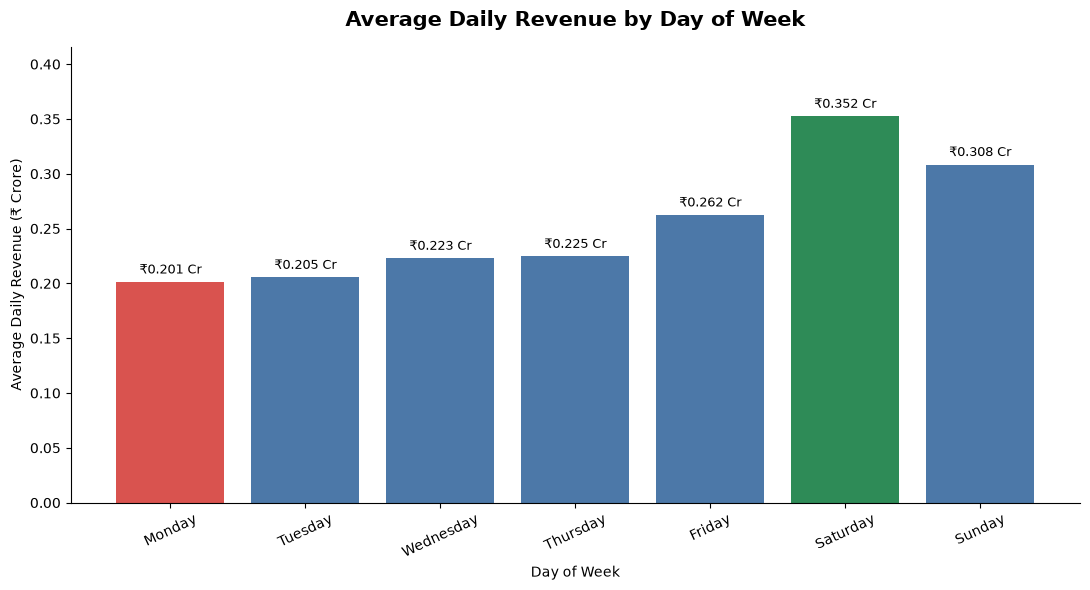

In [356]:
best_day = average_revenue_by_weekday.idxmax()
worst_day = average_revenue_by_weekday.idxmin()

weekday_colors = [
    "#2E8B57" if day == best_day
    else "#D9534F" if day == worst_day
    else "#4C78A8"
    for day in weekday_order
]

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    weekday_order,
    average_revenue_by_weekday_crore,
    color=weekday_colors
)

ax.set_title(
    "Average Daily Revenue by Day of Week",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Daily Revenue (₹ Crore)")

ax.bar_label(
    bars,
    labels=[
        f"₹{value:.3f} Cr"
        for value in average_revenue_by_weekday_crore
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(
    0,
    average_revenue_by_weekday_crore.max() * 1.18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [357]:
best_day_revenue = average_revenue_by_weekday.max()
worst_day_revenue = average_revenue_by_weekday.min()

best_vs_worst_uplift = (
    (best_day_revenue - worst_day_revenue)
    / worst_day_revenue
    * 100
)

weekday_average = average_revenue_by_weekday.loc[
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
].mean()

weekend_average = average_revenue_by_weekday.loc[
    ["Saturday", "Sunday"]
].mean()

weekend_uplift = (
    (weekend_average - weekday_average)
    / weekday_average
    * 100
)

print(
    f"Best-performing day: {best_day} "
    f"(₹{best_day_revenue / 1_00_00_000:.3f} Cr)"
)

print(
    f"Worst-performing day: {worst_day} "
    f"(₹{worst_day_revenue / 1_00_00_000:.3f} Cr)"
)

print(
    f"{best_day} revenue is "
    f"{best_vs_worst_uplift:.1f}% above {worst_day}"
)

print(
    f"Weekend average revenue is "
    f"{weekend_uplift:.1f}% above the weekday average"
)

Best-performing day: Saturday (₹0.352 Cr)
Worst-performing day: Monday (₹0.201 Cr)
Saturday revenue is 75.1% above Monday
Weekend average revenue is 48.0% above the weekday average


In [358]:
monthly_revenue = (
    sales_df.groupby("month")["revenue"]
    .sum()
    .sort_index()
)

monthly_revenue_crore = (
    monthly_revenue / 1_00_00_000
)

monthly_revenue_crore.round(2)

month
2026-01    8.48
2026-02    7.38
2026-03    8.07
2026-04    7.57
2026-05    7.56
2026-06    6.93
Freq: M, Name: revenue, dtype: float64

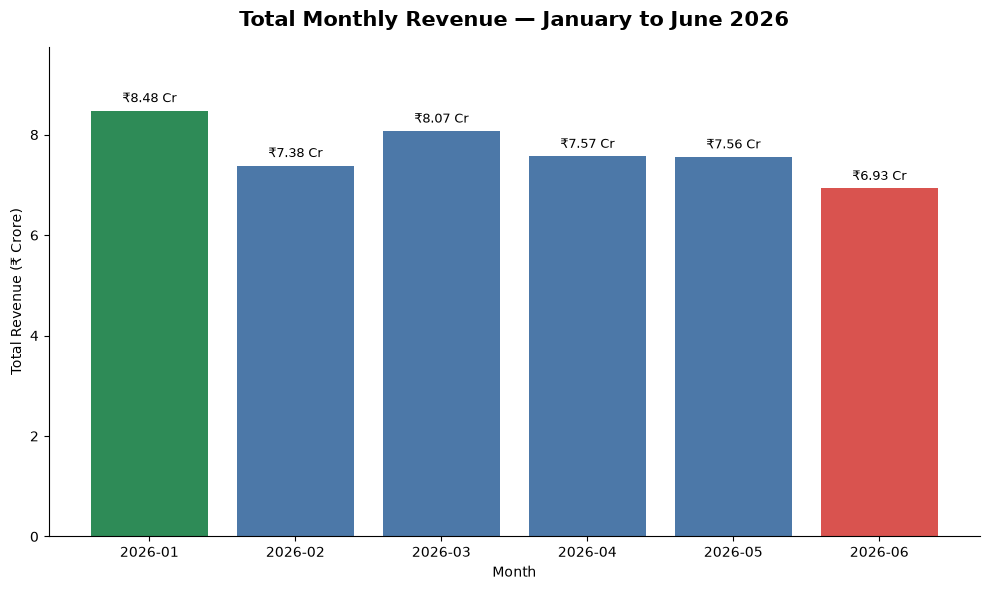

In [359]:
best_month = monthly_revenue.idxmax()
worst_month = monthly_revenue.idxmin()

month_labels = monthly_revenue.index.astype(str)

month_colors = [
    "#2E8B57" if month == best_month
    else "#D9534F" if month == worst_month
    else "#4C78A8"
    for month in monthly_revenue.index
]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    month_labels,
    monthly_revenue_crore,
    color=month_colors
)

ax.set_title(
    "Total Monthly Revenue — January to June 2026",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹ Crore)")

ax.bar_label(
    bars,
    labels=[
        f"₹{value:.2f} Cr"
        for value in monthly_revenue_crore
    ],
    padding=4,
    fontsize=9
)

ax.set_ylim(
    0,
    monthly_revenue_crore.max() * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [360]:
january_revenue = monthly_revenue.iloc[0]
june_revenue = monthly_revenue.iloc[-1]

jan_to_jun_change = (
    (june_revenue - january_revenue)
    / january_revenue
    * 100
)

print(
    f"Best-performing month: {best_month} "
    f"(₹{monthly_revenue.max() / 1_00_00_000:.2f} Cr)"
)

print(
    f"Worst-performing month: {worst_month} "
    f"(₹{monthly_revenue.min() / 1_00_00_000:.2f} Cr)"
)

print(
    f"January-to-June revenue change: "
    f"{jan_to_jun_change:.1f}%"
)

Best-performing month: 2026-01 (₹8.48 Cr)
Worst-performing month: 2026-06 (₹6.93 Cr)
January-to-June revenue change: -18.3%


In [361]:
daily_revenue["month"] = (
    daily_revenue["date"].dt.to_period("M")
)

average_daily_revenue_by_month = (
    daily_revenue.groupby("month")["revenue"]
    .mean()
)

normalized_jan_to_jun_change = (
    (
        average_daily_revenue_by_month.iloc[-1]
        - average_daily_revenue_by_month.iloc[0]
    )
    / average_daily_revenue_by_month.iloc[0]
    * 100
)

print(
    f"January-to-June change after adjusting "
    f"for month length: "
    f"{normalized_jan_to_jun_change:.1f}%"
)

January-to-June change after adjusting for month length: -15.5%


### Business Interpretation and Promotion Recommendation

Saturday generated the highest average daily revenue at approximately **₹0.352 crore**, while Monday generated the lowest at approximately **₹0.201 crore**. Saturday therefore produced roughly **75% more average daily revenue than Monday**, demonstrating a strong weekend sales pattern.

At the monthly level, revenue declined from approximately **₹8.48 crore in January to ₹6.93 crore in June**, a reduction of about **18.3%**. The decline remained meaningful after adjusting for differences in month length, indicating that it is not merely a calendar effect.

If the objective is to stimulate weak demand, I would pilot a targeted Monday flash promotion rather than discounting heavily on Saturday, when customer demand is already strong. The promotion should be tested in selected stores and evaluated using incremental transaction volume, revenue and margin, because the existing observational data cannot prove that a promotion will cause an improvement.

## 5.5 Weekly Revenue Anomaly Identification

Weekly store revenue is analysed to identify unusually low-performing store-week combinations. A store-week is flagged when its revenue falls more than two standard deviations below that store's own average weekly revenue.

In [362]:
sales_df["week_start"] = (
    sales_df["date"]
    - pd.to_timedelta(
        sales_df["date"].dt.dayofweek,
        unit="D"
    )
)

sales_df[
    ["date", "week_start"]
].drop_duplicates().head(10)

,date,week_start
0,2026-01-01,2025-12-29
509,2026-01-02,2025-12-29
1132,2026-01-03,2025-12-29
1928,2026-01-04,2025-12-29
2658,2026-01-05,2026-01-05
3126,2026-01-06,2026-01-05
3632,2026-01-07,2026-01-05
4143,2026-01-08,2026-01-05
4651,2026-01-09,2026-01-05
5245,2026-01-10,2026-01-05


In [363]:
weekly_store_revenue = (
    sales_df.groupby(
        ["store_id", "store_city", "week_start"],
        as_index=False
    )
    .agg(
        weekly_revenue=("revenue", "sum"),
        days_observed=("date", "nunique")
    )
)

weekly_store_revenue.head()

,store_id,store_city,week_start,weekly_revenue,days_observed
0,S01,Vijayawada,2025-12-29,1207561.87,4
1,S01,Vijayawada,2026-01-05,2350618.81,7
2,S01,Vijayawada,2026-01-12,2316840.47,7
3,S01,Vijayawada,2026-01-19,2579278.37,7
4,S01,Vijayawada,2026-01-26,2000527.75,7


In [364]:
weekly_store_revenue[
    weekly_store_revenue["days_observed"] < 7
][
    ["week_start", "days_observed"]
].drop_duplicates()

,week_start,days_observed
0,2025-12-29,4
26,2026-06-29,2


In [365]:
complete_weekly_revenue = (
    weekly_store_revenue[
        weekly_store_revenue["days_observed"] == 7
    ]
    .copy()
)

print(
    f"Store-week records before filtering: "
    f"{len(weekly_store_revenue)}"
)

print(
    f"Complete store-week records retained: "
    f"{len(complete_weekly_revenue)}"
)

Store-week records before filtering: 324
Complete store-week records retained: 300


In [366]:
store_weekly_stats = (
    complete_weekly_revenue.groupby("store_id")[
        "weekly_revenue"
    ]
)

complete_weekly_revenue["store_weekly_mean"] = (
    store_weekly_stats.transform("mean")
)

complete_weekly_revenue["store_weekly_std"] = (
    store_weekly_stats.transform("std")
)

complete_weekly_revenue["lower_threshold"] = (
    complete_weekly_revenue["store_weekly_mean"]
    - 2 * complete_weekly_revenue["store_weekly_std"]
)

In [367]:
complete_weekly_revenue["is_anomaly"] = (
    complete_weekly_revenue["weekly_revenue"]
    < complete_weekly_revenue["lower_threshold"]
)

In [368]:
weekly_anomalies = (
    complete_weekly_revenue[
        complete_weekly_revenue["is_anomaly"]
    ]
    .copy()
    .sort_values(
        ["store_id", "week_start"]
    )
)

weekly_anomalies[
    [
        "store_id",
        "store_city",
        "week_start",
        "weekly_revenue",
        "store_weekly_mean",
        "lower_threshold"
    ]
].round({
    "weekly_revenue": 2,
    "store_weekly_mean": 2,
    "lower_threshold": 2
})

,store_id,store_city,week_start,weekly_revenue,store_weekly_mean,lower_threshold
47,S02,Vijayawada,2026-05-18,1173289.36,1627618.52,1174000.07
104,S04,Guntur,2026-06-08,1137480.32,1598816.04,1141544.87
114,S05,Rajahmundry,2026-02-09,655732.19,977406.87,723179.77
257,S10,Nellore,2026-04-06,505536.54,867129.31,539510.52


In [369]:
weekly_anomalies["z_score"] = (
    (
        weekly_anomalies["weekly_revenue"]
        - weekly_anomalies["store_weekly_mean"]
    )
    / weekly_anomalies["store_weekly_std"]
)

weekly_anomalies["revenue_gap_from_average"] = (
    weekly_anomalies["store_weekly_mean"]
    - weekly_anomalies["weekly_revenue"]
)

weekly_anomalies[
    [
        "store_id",
        "store_city",
        "week_start",
        "weekly_revenue",
        "revenue_gap_from_average",
        "z_score"
    ]
].round({
    "weekly_revenue": 2,
    "revenue_gap_from_average": 2,
    "z_score": 2
})

,store_id,store_city,week_start,weekly_revenue,revenue_gap_from_average,z_score
47,S02,Vijayawada,2026-05-18,1173289.36,454329.16,-2.00
104,S04,Guntur,2026-06-08,1137480.32,461335.72,-2.02
114,S05,Rajahmundry,2026-02-09,655732.19,321674.68,-2.53
257,S10,Nellore,2026-04-06,505536.54,361592.77,-2.21


In [370]:
weekly_anomalies["gap_from_average_pct"] = (
    weekly_anomalies["revenue_gap_from_average"]
    / weekly_anomalies["store_weekly_mean"]
    * 100
)

anomaly_display = weekly_anomalies[
    [
        "store_id",
        "store_city",
        "week_start",
        "weekly_revenue",
        "revenue_gap_from_average",
        "gap_from_average_pct",
        "z_score"
    ]
].copy()

anomaly_display = anomaly_display.round({
    "weekly_revenue": 2,
    "revenue_gap_from_average": 2,
    "gap_from_average_pct": 1,
    "z_score": 2
})

anomaly_display

,store_id,store_city,week_start,weekly_revenue,revenue_gap_from_average,gap_from_average_pct,z_score
47,S02,Vijayawada,2026-05-18,1173289.36,454329.16,27.9,-2.00
104,S04,Guntur,2026-06-08,1137480.32,461335.72,28.9,-2.02
114,S05,Rajahmundry,2026-02-09,655732.19,321674.68,32.9,-2.53
257,S10,Nellore,2026-04-06,505536.54,361592.77,41.7,-2.21


### Anomaly Interpretation

Four complete store-weeks fell more than two standard deviations below their respective store averages. These are statistical anomalies that require investigation, not records that should automatically be removed.

| Store-week | Finding | Possible business reason |
|---|---|---|
| **S02, Vijayawada — 18 May 2026** | Revenue was ₹11.73 lakh, approximately 27.9% below its weekly average. | A local competitor promotion may have temporarily reduced customer traffic. |
| **S04, Guntur — 8 June 2026** | Revenue was ₹11.37 lakh, approximately 28.9% below average. | Reduced operating hours or a local event may have affected store footfall. |
| **S05, Rajahmundry — 9 February 2026** | Revenue was ₹6.56 lakh, approximately 32.9% below average. | A supply disruption or stockout of high-revenue products may have affected sales. |
| **S10, Nellore — 6 April 2026** | Revenue was ₹5.06 lakh, approximately 41.7% below average. | A pricing issue or competitor activity may have temporarily reduced demand. |

These are hypotheses rather than confirmed causes. Inventory availability, operating hours, promotion history, local events and competitor information would be needed for root-cause confirmation.

## 5.6 Business Recommendation

The most important finding is the sustained decline in **Electronics revenue**, which fell from approximately **₹4.57 crore in January to ₹2.97 crore in June**, a reduction of about **₹1.60 crore or 35%**. Because this decline remained substantial after adjusting for month length, I recommend that the operations team prioritise an Electronics root-cause review and run a controlled promotional pilot rather than immediately applying discounts across all stores.

The pilot should compare selected stores against similar non-promoted stores and measure incremental transactions, units sold, revenue and margin. Before committing significant Q3 promotional spending, additional data on product-level inventory availability, profit margins, competitor pricing and previous campaign performance would be required.

### Data Enrichment Recommendations

The available transaction data is sufficient to identify store, category and
time-based performance patterns. However, it cannot independently confirm the
business reasons behind those patterns.

For stronger root-cause analysis, the following data would be useful:

| Additional data | Analytical value |
|---|---|
| Store footfall | Determines whether low revenue is associated with fewer visitors or lower conversion |
| Store size and operating hours | Enables fair comparison between stores with different capacity and availability |
| Inventory and stockout records | Tests whether category declines were caused by product unavailability |
| Product cost and gross margin | Measures profitability instead of relying only on revenue |
| Promotion history | Evaluates whether discounts produced incremental sales |
| Competitor pricing | Tests whether external price differences affected demand |
| Sales targets or budgets | Distinguishes low relative performance from actual target underperformance |
| Holiday and local-event calendar | Provides context for unusual daily or weekly sales patterns |

These variables should be treated as future data-enrichment requirements.
Without them, possible causes remain hypotheses rather than confirmed
explanations.

# Part 2 — Automating the Pulse: Data Pipeline and Validation

## 5.7 Understand the JSON Structure

The clean weekly JSON file simulates a successful API response containing metadata and seven days of retail transaction data. Its structure is examined before extracting and processing the records.

In [371]:
with open(                            #loads the clean json
    "MUC01_Weekly_Sales_API_Response.json",
    "r",
    encoding="utf-8"
) as file:
    api_response = json.load(file)

In [372]:
print("Top-level type:", type(api_response).__name__)
print("Top-level keys:", list(api_response.keys()))

Top-level type: dict
Top-level keys: ['status', 'request_id', 'generated_at', 'period', 'record_count', 'data']


In [373]:
for key, value in api_response.items():
    print(f"{key}: {type(value).__name__}")                                         #inspect the type of each value

status: str
request_id: str
generated_at: str
period: dict
record_count: int
data: list


In [374]:
print(
    f"Transactions inside data: "            #checking number of records in the data list of the API response
    f"{len(api_response['data']):,}"
)

Transactions inside data: 4,291


In [375]:
api_response["data"][0]

{'transaction_id': 'TXN103546',
 'date': '2026-06-24',
 'store_id': 'S01',
 'store_city': 'Vijayawada',
 'category': 'Electronics',
 'product_name': 'Headphones',
 'units_sold': 3,
 'unit_price': 13899.23,
 'revenue': 41697.69,
 'discount_pct': 0}

In [376]:
metadata = {                        #inspecting the metadata of the API response
    "status": api_response["status"],
    "request_id": api_response["request_id"],
    "generated_at": api_response["generated_at"],
    "period": api_response["period"],
    "record_count": api_response["record_count"]
}

metadata

{'status': 'success',
 'request_id': 'RTL-20260630-001',
 'generated_at': '2026-06-30T08:00:00Z',
 'period': {'from': '2026-06-24', 'to': '2026-06-30'},
 'record_count': 4291}

In [377]:
print("Status:", api_response["status"])
print("Request ID:", api_response["request_id"])
print("Generated at:", api_response["generated_at"])
print("Period from:", api_response["period"]["from"])
print("Period to:", api_response["period"]["to"])
print("Metadata record count:", api_response["record_count"])
print("Actual records received:", len(api_response["data"]))

Status: success
Request ID: RTL-20260630-001
Generated at: 2026-06-30T08:00:00Z
Period from: 2026-06-24
Period to: 2026-06-30
Metadata record count: 4291
Actual records received: 4291


### Understanding the API Response

1. **Top-level structure:** The JSON has a dictionary as its top-level structure. It contains the keys `status`, `request_id`, `generated_at`, `period`, `record_count` and `data`.

2. **Transaction location:** The actual weekly transaction records are stored inside the `data` key as a list of dictionaries. Each dictionary represents one transaction and contains the same business fields used in the historical CSV.

3. **Real-world API usage:** In a production environment, a retail API could return weekly sales transactions together with metadata describing the request, generation time, reporting period and expected record count. A downstream pipeline would first verify the response status and metadata before validating and processing the transaction records.

## 5.8 Ingest and Parse the API Response

The transaction records are extracted from the clean API response and converted into a Pandas DataFrame. The payload metadata is then reconciled with the actual records received before further processing.

In [378]:
weekly_sales_df = pd.DataFrame(
    api_response["data"]
)

print(
    f"Weekly DataFrame created with "
    f"{weekly_sales_df.shape[0]:,} rows and "
    f"{weekly_sales_df.shape[1]} columns."
)

weekly_sales_df.head()

Weekly DataFrame created with 4,291 rows and 10 columns.


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1,2118.31,2118.31,0


In [407]:

weekly_sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4291 entries, 0 to 4290
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  4291 non-null   str           
 1   date            4291 non-null   datetime64[us]
 2   store_id        4291 non-null   str           
 3   store_city      4291 non-null   str           
 4   category        4291 non-null   str           
 5   product_name    4291 non-null   str           
 6   units_sold      4291 non-null   int64         
 7   unit_price      4291 non-null   float64       
 8   revenue         4291 non-null   float64       
 9   discount_pct    4291 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(5)
memory usage: 335.4 KB


In [379]:
parsed_weekly_dates = pd.to_datetime(
    weekly_sales_df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

invalid_weekly_dates = parsed_weekly_dates.isna().sum()

print(f"Invalid weekly dates: {invalid_weekly_dates}")

weekly_sales_df["date"] = parsed_weekly_dates

Invalid weekly dates: 0


In [380]:
expected_record_count = api_response["record_count"]
actual_record_count = len(weekly_sales_df)

print(f"Expected records: {expected_record_count:,}")
print(f"Actual records: {actual_record_count:,}")

if expected_record_count != actual_record_count:
    raise ValueError(
        "Record-count mismatch: "
        f"metadata expected {expected_record_count:,}, "
        f"but {actual_record_count:,} records were received."
    )

print("Record-count validation: PASSED")

Expected records: 4,291
Actual records: 4,291
Record-count validation: PASSED


In [381]:
metadata_start_date = pd.to_datetime(
    api_response["period"]["from"]
)

metadata_end_date = pd.to_datetime(
    api_response["period"]["to"]
)

actual_start_date = weekly_sales_df["date"].min()
actual_end_date = weekly_sales_df["date"].max()

print(
    f"Metadata period: "
    f"{metadata_start_date.date()} to "
    f"{metadata_end_date.date()}"
)

print(
    f"Actual data period: "
    f"{actual_start_date.date()} to "
    f"{actual_end_date.date()}"
)

if (
    actual_start_date != metadata_start_date
    or actual_end_date != metadata_end_date
):
    raise ValueError(
        "The transaction date range does not match "
        "the API metadata period."
    )

print("Date-range validation: PASSED")

Metadata period: 2026-06-24 to 2026-06-30
Actual data period: 2026-06-24 to 2026-06-30
Date-range validation: PASSED


In [382]:
weekly_sales_df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1,2118.31,2118.31,0


### Ingestion and Metadata Validation

The clean API payload contained **4,291 transaction records** covering **24 June to 30 June 2026**. The transaction list was successfully converted into a Pandas DataFrame, the date column was converted to datetime format, and both the record count and reporting period matched the JSON metadata.

A production pipeline must compare the metadata record count with the number of records actually received because a successful API response does not guarantee that the payload is complete. If the counts differ, continuing could produce incomplete revenue totals and misleading business alerts; therefore, the pipeline should log the mismatch and halt processing.

## 5.9 Validate the Data Before Processing

The corrupt weekly JSON payload is used to test whether the pipeline can detect missing values, non-positive revenue and invalid store IDs before performing any transformation or reporting.

In [383]:
with open(
    "MUC01_Weekly_Sales_API_Corrupt.json",
    "r",
    encoding="utf-8"
) as file:
    corrupt_api_response = json.load(file)

In [384]:
corrupt_weekly_df = pd.DataFrame(
    corrupt_api_response["data"]
)

print(
    f"Corrupt payload loaded with "
    f"{len(corrupt_weekly_df):,} records."
)

corrupt_weekly_df.head()

Corrupt payload loaded with 4,291 records.


,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN103546,2026-06-24,S01,Vijayawada,Electronics,Headphones,3.0,13899.23,41697.69,0
1,TXN103547,2026-06-24,S01,Vijayawada,Apparel,Formal Shirt,2.0,1470.83,2941.66,0
2,TXN103548,2026-06-24,S01,Vijayawada,Apparel,Saree,4.0,2706.78,10827.12,0
3,TXN103549,2026-06-24,S01,Vijayawada,Apparel,Saree,3.0,3257.93,9773.79,0
4,TXN103550,2026-06-24,S01,Vijayawada,Apparel,Jeans,1.0,2118.31,2118.31,0


In [385]:
corrupt_weekly_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4291 entries, 0 to 4290
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  4291 non-null   str    
 1   date            4291 non-null   str    
 2   store_id        4291 non-null   str    
 3   store_city      4291 non-null   str    
 4   category        4291 non-null   str    
 5   product_name    4291 non-null   str    
 6   units_sold      4290 non-null   float64
 7   unit_price      4291 non-null   float64
 8   revenue         4291 non-null   float64
 9   discount_pct    4291 non-null   int64  
dtypes: float64(3), int64(1), str(6)
memory usage: 335.4 KB


In [386]:
corrupt_weekly_df["date"] = pd.to_datetime(
    corrupt_weekly_df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

In [387]:
print(
    "Date type after conversion:",
    corrupt_weekly_df["date"].dtype
)

Date type after conversion: datetime64[us]


In [388]:
def validate_sales_data(dataframe, valid_store_ids):
    issues = []

    # Rule 1: Check every column for null values
    null_locations = np.argwhere(
        dataframe.isna().to_numpy()
    )

    for row_position, column_position in null_locations:
        row_index = dataframe.index[row_position]
        column_name = dataframe.columns[column_position]

        issues.append({
            "type": "Null value",
            "row": row_index,
            "column": column_name,
            "value": None
        })

    # Rule 2: Revenue must be greater than zero
    invalid_revenue_rows = dataframe[
        dataframe["revenue"] <= 0
    ]

    for row_index, row in invalid_revenue_rows.iterrows():
        issues.append({
            "type": "Non-positive revenue",
            "row": row_index,
            "column": "revenue",
            "value": row["revenue"]
        })

    # Rule 3: Store ID must exist in S01–S12
    invalid_store_rows = dataframe[
        ~dataframe["store_id"].isin(valid_store_ids)
    ]

    for row_index, row in invalid_store_rows.iterrows():
        issues.append({
            "type": "Invalid store ID",
            "row": row_index,
            "column": "store_id",
            "value": row["store_id"]
        })

    # Count each issue type
    null_count = sum(
        issue["type"] == "Null value"
        for issue in issues
    )

    revenue_issue_count = sum(
        issue["type"] == "Non-positive revenue"
        for issue in issues
    )

    store_issue_count = sum(
        issue["type"] == "Invalid store ID"
        for issue in issues
    )

    # Print pipeline-friendly validation summary
    print("Validation Summary")
    print("------------------")
    print(f"Total records checked: {len(dataframe):,}")
    print(f"Null values found: {null_count}")
    print(
        f"Non-positive revenue values found: "
        f"{revenue_issue_count}"
    )
    print(
        f"Invalid store IDs found: "
        f"{store_issue_count}"
    )

    if issues:
        print(
            f"Status: FAILED — "
            f"{len(issues)} issue(s) detected. "
            f"Pipeline halted."
        )

        print("\nIssue Details")
        print("-------------")

        for issue in issues:
            print(
                f"Row {issue['row']} | "
                f"Column: {issue['column']} | "
                f"Issue: {issue['type']} | "
                f"Value: {issue['value']}"
            )
    else:
        print(
            "Status: PASSED — No issues detected. "
            "Pipeline may continue."
        )

    return {
        "is_valid": len(issues) == 0,
        "issue_count": len(issues),
        "issues": issues
    }

In [389]:
VALID_STORE_IDS = {
    f"S{store_number:02d}"
    for store_number in range(1, 13)
}

print(sorted(VALID_STORE_IDS))

['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12']


In [390]:
corrupt_validation_result = validate_sales_data(
    corrupt_weekly_df,
    VALID_STORE_IDS
)

Validation Summary
------------------
Total records checked: 4,291
Null values found: 1
Non-positive revenue values found: 1
Invalid store IDs found: 1
Status: FAILED — 3 issue(s) detected. Pipeline halted.

Issue Details
-------------
Row 12 | Column: units_sold | Issue: Null value | Value: None
Row 5 | Column: revenue | Issue: Non-positive revenue | Value: -150.0
Row 20 | Column: store_id | Issue: Invalid store ID | Value: S99


In [391]:
clean_validation_result = validate_sales_data(
    weekly_sales_df,
    VALID_STORE_IDS
)

Validation Summary
------------------
Total records checked: 4,291
Null values found: 0
Non-positive revenue values found: 0
Invalid store IDs found: 0
Status: PASSED — No issues detected. Pipeline may continue.


In [392]:
if clean_validation_result["is_valid"]:
    print("Clean payload approved for transformation.")
else:
    print("Clean payload rejected. Pipeline halted.")

if corrupt_validation_result["is_valid"]:
    print("Corrupt payload approved for transformation.")
else:
    print("Corrupt payload rejected. Pipeline halted.")

Clean payload approved for transformation.
Corrupt payload rejected. Pipeline halted.


### Validation Decision

The validation function detected all three intentional issues in the corrupt payload and prevented it from continuing to transformation. The same function allowed the clean payload to proceed, demonstrating that the validation logic is reusable rather than designed only for one file.

For this reporting pipeline, corrupt data should cause the pipeline to halt and log all detected issues. Automatically correcting the values would require unsupported assumptions, while silently skipping the affected rows could produce incomplete revenue totals; the payload should therefore be quarantined and reprocessed after correction by the source system.

## 5.10 Transform and Aggregate

The validated clean weekly data is transformed into store-level and category-level summaries. Weekly category performance is then compared with the six-month historical baseline to identify material declines.

In [393]:
if not clean_validation_result["is_valid"]:
    raise ValueError(
        "Clean weekly data failed validation. "
        "Transformation has been halted."
    )

print("Validation passed. Transformation started.")

Validation passed. Transformation started.


In [394]:
weekly_revenue_by_store = (
    weekly_sales_df.groupby(
        ["store_id", "store_city"],
        as_index=False
    )["revenue"]
    .sum()
    .sort_values(
        "revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

weekly_revenue_by_store

,store_id,store_city,revenue
0,S03,Guntur,2037560.19
1,S01,Vijayawada,1608043.08
2,S06,Rajahmundry,1565006.35
3,S07,Tirupati,1349795.33
4,S04,Guntur,1285265.18
5,S08,Tirupati,1269260.54
6,S11,Kakinada,1249928.27
7,S02,Vijayawada,1218330.60
8,S09,Nellore,976322.30
9,S05,Rajahmundry,941961.76


In [395]:
weekly_revenue_by_category = (
    weekly_sales_df.groupby(
        "category",
        as_index=False
    )["revenue"]
    .sum()
    .sort_values(
        "revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

weekly_revenue_by_category

,category,revenue
0,Electronics,5764693.85
1,Apparel,3228573.10
2,Home & Kitchen,2847057.00
3,Grocery,1617278.70
4,Personal Care,1557807.63


In [396]:
top_store_this_week = (
    weekly_revenue_by_store.iloc[0]
)

print(
    f"Top store this week: "
    f"{top_store_this_week['store_id']} — "
    f"{top_store_this_week['store_city']} "
    f"(₹{top_store_this_week['revenue'] / 1_00_000:.2f} lakh)"
)

Top store this week: S03 — Guntur (₹20.38 lakh)


In [397]:
historical_daily_category_revenue = (
    sales_df.groupby(
        ["date", "category"],
        as_index=False
    )["revenue"]
    .sum()
)

historical_category_baseline = (
    historical_daily_category_revenue.groupby(
        "category",
        as_index=False
    )["revenue"]
    .mean()
    .rename(
        columns={
            "revenue": "historical_daily_average"
        }
    )
)

historical_category_baseline

,category,historical_daily_average
0,Apparel,3.838651e+05
1,Electronics,1.251534e+06
2,Grocery,2.337159e+05
3,Home & Kitchen,4.521863e+05
4,Personal Care,2.190528e+05


In [398]:
weekly_daily_category_revenue = (
    weekly_sales_df.groupby(
        ["date", "category"],
        as_index=False
    )["revenue"]
    .sum()
)

weekly_category_daily_average = (
    weekly_daily_category_revenue.groupby(
        "category",
        as_index=False
    )["revenue"]
    .mean()
    .rename(
        columns={
            "revenue": "weekly_daily_average"
        }
    )
)

weekly_category_daily_average

,category,weekly_daily_average
0,Apparel,461224.728571
1,Electronics,823527.692857
2,Grocery,231039.814286
3,Home & Kitchen,406722.428571
4,Personal Care,222543.947143


In [399]:
category_comparison = (
    historical_category_baseline.merge(
        weekly_category_daily_average,
        on="category",
        how="inner"
    )
)

category_comparison["change_vs_baseline_pct"] = (
    (
        category_comparison["weekly_daily_average"]
        - category_comparison["historical_daily_average"]
    )
    / category_comparison["historical_daily_average"]
    * 100
)

category_comparison.round(2)

,category,historical_daily_average,weekly_daily_average,change_vs_baseline_pct
0,Apparel,383865.14,461224.73,20.15
1,Electronics,1251534.39,823527.69,-34.20
2,Grocery,233715.92,231039.81,-1.15
3,Home & Kitchen,452186.31,406722.43,-10.05
4,Personal Care,219052.82,222543.95,1.59


In [400]:
category_alert = (
    category_comparison[
        category_comparison["change_vs_baseline_pct"] < -20
    ]
    .copy()
    .sort_values("change_vs_baseline_pct")
    .reset_index(drop=True)
)

category_alert.round(2)

,category,historical_daily_average,weekly_daily_average,change_vs_baseline_pct
0,Electronics,1251534.39,823527.69,-34.2


In [401]:
if category_alert.empty:
    print("No category alerts triggered.")
else:
    print("Category Alerts")
    print("---------------")

    for _, row in category_alert.iterrows():
        print(
            f"{row['category']}: "
            f"{abs(row['change_vs_baseline_pct']):.1f}% "
            f"below the six-month daily baseline"
        )

Category Alerts
---------------
Electronics: 34.2% below the six-month daily baseline


### Weekly Transformation Findings

S03 in Guntur was the highest-revenue store during the seven-day period, generating approximately **₹20.38 lakh**, even though S01 led the complete six-month ranking. This demonstrates why the business requires a refreshed weekly view rather than relying only on historical rankings.

Electronics triggered the category alert because its average daily revenue during the current week was approximately **34.2% below the six-month historical daily average**. The comparison uses equivalent daily measures to avoid comparing a seven-day total directly with a one-day baseline.

The supplied historical CSV includes the current JSON reporting week. This follows the assignment requirement, but a production pipeline should normally calculate the baseline using only dates before the current reporting period to prevent the current week from influencing its own benchmark.

## 5.11 Generate the Weekly Pipeline Summary

A reusable function combines JSON ingestion, metadata reconciliation, validation, transformation and reporting. All figures in the summary are calculated dynamically from the supplied clean weekly payload and historical CSV baseline.

In [402]:
def format_inr(amount):
    amount = round(float(amount), 2)
    whole, decimal = f"{amount:.2f}".split(".")

    if len(whole) <= 3:
        formatted_whole = whole
    else:
        last_three = whole[-3:]
        remaining = whole[:-3]

        groups = []

        while remaining:
            groups.append(remaining[-2:])
            remaining = remaining[:-2]

        formatted_whole = (
            ",".join(reversed(groups))
            + ","
            + last_three
        )

    return f"₹{formatted_whole}.{decimal}"

In [403]:
print(format_inr(2037560.19))  #testing the function with a sample amount

₹20,37,560.19


In [404]:
def generate_weekly_summary(
    json_file_path,
    historical_df
):
    # 1. Ingest JSON
    with open(
        json_file_path,
        "r",
        encoding="utf-8"
    ) as file:
        response = json.load(file)

    # 2. Check API response status
    if response.get("status") != "success":
        print(
            "Pipeline status: FAILED — "
            "API response was not successful."
        )
        return None

    # 3. Parse transaction records
    weekly_df = pd.DataFrame(
        response.get("data", [])
    )

    # 4. Reconcile metadata record count
    expected_count = response.get("record_count")
    actual_count = len(weekly_df)

    if expected_count != actual_count:
        print(
            "Pipeline status: FAILED — "
            f"Expected {expected_count:,} records, "
            f"but received {actual_count:,}."
        )
        return None

    # 5. Convert date
    weekly_df["date"] = pd.to_datetime(
        weekly_df["date"],
        format="%Y-%m-%d",
        errors="coerce"
    )

    # 6. Validate transaction data
    validation_result = validate_sales_data(
        weekly_df,
        VALID_STORE_IDS
    )

    if not validation_result["is_valid"]:
        return None

    # 7. Aggregate store revenue
    store_summary = (
        weekly_df.groupby(
            ["store_id", "store_city"],
            as_index=False
        )["revenue"]
        .sum()
        .sort_values(
            "revenue",
            ascending=False
        )
        .reset_index(drop=True)
    )

    top_store = store_summary.iloc[0]
    bottom_store = store_summary.iloc[-1]

    # 8. Calculate historical daily baseline
    historical_daily = (
        historical_df.groupby(
            ["date", "category"],
            as_index=False
        )["revenue"]
        .sum()
    )

    historical_baseline = (
        historical_daily.groupby(
            "category",
            as_index=False
        )["revenue"]
        .mean()
        .rename(columns={
            "revenue": "historical_daily_average"
        })
    )

    # 9. Calculate current weekly daily average
    weekly_daily = (
        weekly_df.groupby(
            ["date", "category"],
            as_index=False
        )["revenue"]
        .sum()
    )

    weekly_average = (
        weekly_daily.groupby(
            "category",
            as_index=False
        )["revenue"]
        .mean()
        .rename(columns={
            "revenue": "weekly_daily_average"
        })
    )

    # 10. Compare current week with baseline
    category_comparison = (
        historical_baseline.merge(
            weekly_average,
            on="category",
            how="inner"
        )
    )

    category_comparison[
        "change_vs_baseline_pct"
    ] = (
        (
            category_comparison[
                "weekly_daily_average"
            ]
            - category_comparison[
                "historical_daily_average"
            ]
        )
        / category_comparison[
            "historical_daily_average"
        ]
        * 100
    )

    alerts = category_comparison[
        category_comparison[
            "change_vs_baseline_pct"
        ] < -20
    ]

    no_alerts = category_comparison[
        category_comparison[
            "change_vs_baseline_pct"
        ] >= -20
    ]

    # 11. Read reporting period
    period_from = response["period"]["from"]
    period_to = response["period"]["to"]

    # 12. Print weekly report
    print(
        "\n=== RETAIL SALES PULSE — "
        "WEEKLY SUMMARY ==="
    )
    print(
        f"Period: {period_from} to {period_to}"
    )
    print(
        f"Records processed: {actual_count:,}"
    )
    print(
        f"Top store this week: "
        f"{top_store['store_id']} — "
        f"{top_store['store_city']} "
        f"({format_inr(top_store['revenue'])})"
    )
    print(
        f"Bottom store this week: "
        f"{bottom_store['store_id']} — "
        f"{bottom_store['store_city']} "
        f"({format_inr(bottom_store['revenue'])})"
    )

    if alerts.empty:
        print("Category alert: None")
    else:
        for _, row in alerts.iterrows():
            print(
                f"Category alert: "
                f"{row['category']} revenue down "
                f"{abs(row['change_vs_baseline_pct']):.1f}% "
                f"vs six-month baseline"
            )

    print(
        "No alert: "
        + ", ".join(no_alerts["category"])
    )

    print(
        "Pipeline status: "
        "COMPLETED SUCCESSFULLY"
    )

    return {
        "weekly_data": weekly_df,
        "store_summary": store_summary,
        "category_comparison": category_comparison,
        "alerts": alerts
    }

In [405]:
weekly_pipeline_result = generate_weekly_summary(
    "MUC01_Weekly_Sales_API_Response.json",
    sales_df
)

Validation Summary
------------------
Total records checked: 4,291
Null values found: 0
Non-positive revenue values found: 0
Invalid store IDs found: 0
Status: PASSED — No issues detected. Pipeline may continue.

=== RETAIL SALES PULSE — WEEKLY SUMMARY ===
Period: 2026-06-24 to 2026-06-30
Records processed: 4,291
Top store this week: S03 — Guntur (₹20,37,560.19)
Bottom store this week: S10 — Nellore (₹6,27,119.87)
Category alert: Electronics revenue down 34.2% vs six-month baseline
No alert: Apparel, Grocery, Home & Kitchen, Personal Care
Pipeline status: COMPLETED SUCCESSFULLY


### Monday Email Enhancement

If this summary were emailed to the Head of Retail Operations every Monday, I would include week-over-week and target comparisons, the size of each performance gap and a short list of stores or categories requiring action. I would also add compact trend charts, the data-refresh timestamp, validation status and a link to the detailed report. If validation failed, the business report should not be sent; instead, the responsible data team should receive an exception alert.

### Baseline Limitation

The supplied six-month CSV includes transactions from the weekly reporting
period of 24–30 June 2026. Therefore, the evaluated week partly contributes
to its own six-month benchmark.

The assignment requirement was followed for this analysis. However, in a
production pipeline, the historical baseline should use only dates before
the reporting week. This avoids baseline contamination and produces a fairer
comparison with previously available performance.